<a href="https://colab.research.google.com/github/nguyenduyvu61107/BTAINGUYENDUYVU2026/blob/main/Nh%E1%BA%ADn_di%E1%BB%87n_ti%E1%BB%81n_vi%E1%BB%87t.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

 Tìm thấy mô hình có sẵn!
 Danh sách mệnh giá nhận diện: ['000000', '000200', '000500', '001000', '002000', '005000', '010000', '020000', '050000', '100000', '200000', '500000']
 Hệ thống kích hoạt thành công 

MÔ HÌNH ĐÃ SẴN SÀNG


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


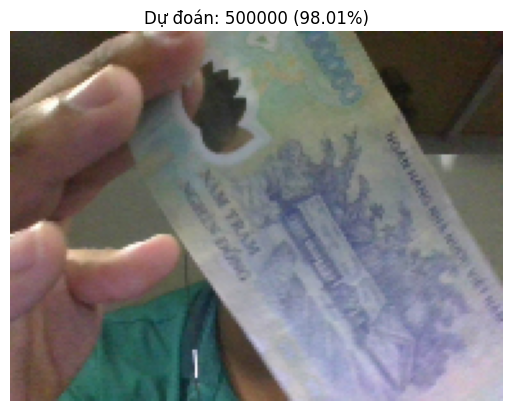

Tờ tiền trên ảnh có mệnh giá là: 500000 (98.01%)


In [14]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models, applications
from tensorflow.keras.preprocessing.image import ImageDataGenerator, img_to_array, load_img
from google.colab import output
from PIL import Image
import io
import base64
import kagglehub

model_save_path = '/content/model_tien_vietnam.keras'

class_names = ['000000', '000200', '000500', '001000', '002000', '005000',
               '010000', '020000', '050000', '100000', '200000', '500000']

if os.path.exists(model_save_path):
    print(" Tìm thấy mô hình có sẵn!")
    model_cnn = models.load_model(model_save_path)
    print(f" Danh sách mệnh giá nhận diện: {class_names}")
    print(" Hệ thống kích hoạt thành công ")
else:
    print("⚠️ Không tìm thấy mô hình sẵn. Tiến hành tải data và huấn luyện mới...")
    print(" Đang tải bộ dữ liệu tiền Việt Nam...")
    path = kagglehub.dataset_download("nguyentrongdai/vietnamese-currency")

    extracted_content = os.listdir(path)
    if 'dataset' in extracted_content:
        data_dir = os.path.join(path, 'dataset')
    elif 'Vietnamese currency' in extracted_content:
        data_dir = os.path.join(path, 'Vietnamese currency')
    else:
        data_dir = path

    datagen = ImageDataGenerator(
        rescale=1./255, rotation_range=20, width_shift_range=0.1, height_shift_range=0.1,
        shear_range=0.1, zoom_range=0.1, horizontal_flip=True, fill_mode='nearest', validation_split=0.2
    )

    train_generator = datagen.flow_from_directory(
        data_dir, target_size=(128, 128), batch_size=32, class_mode='categorical', subset='training'
    )
    val_generator = datagen.flow_from_directory(
        data_dir, target_size=(128, 128), batch_size=32, class_mode='categorical', subset='validation'
    )

    base_model = applications.MobileNetV2(input_shape=(128, 128, 3), include_top=False, weights='imagenet')
    base_model.trainable = False

    model_cnn = models.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(len(class_names), activation='softmax')
    ])

    model_cnn.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

    device_name = "/GPU:0" if tf.config.list_physical_devices('GPU') else "/CPU:0"
    print(f"Thiết bị đang thực thi huấn luyện: {device_name}")

    with tf.device(device_name):
        model_cnn.fit(train_generator, validation_data=val_generator, epochs=10)

    print("Huấn luyện thành công")
    model_cnn.save(model_save_path)
    print(f"ĐÃ LƯU mô hình tại đường dẫn: {model_save_path}")

def predict_pasted_image(img_base64):
    img_data = base64.b64decode(img_base64.split(',')[1])
    img = Image.open(io.BytesIO(img_data)).convert('RGB')

    img_resized = img.resize((128, 128))
    img_array = img_to_array(img_resized)
    img_array = np.expand_dims(img_array, axis=0) / 255.0

    predictions = model_cnn.predict(img_array)
    best_match_idx = np.argmax(predictions[0])
    predicted_class = class_names[best_match_idx]
    confidence = predictions[0][best_match_idx] * 100

    plt.imshow(img)
    plt.axis('off')
    plt.title(f"Dự đoán: {predicted_class} ({confidence:.2f}%)")
    plt.show()
    print(f"Tờ tiền trên ảnh có mệnh giá là: {predicted_class} ({confidence:.2f}%)")

output.register_callback('notebook.predict_pasted_image', predict_pasted_image)

from IPython.display import HTML
html_input = """
<div style="border: 3px dashed #4CAF50; padding: 20px; text-align: center; background-color: #f9f9f9; border-radius: 10px; cursor: pointer;" id="paste-zone">
  <p style="font-size: 16px; font-weight: bold; color: #333;">Nhấn chuột vào đây và nhấn (CTRL + V) để dán ảnh</p>
  <p style="font-size: 13px; color: #666;">...</p>
</div>
<script>
  document.getElementById('paste-zone').addEventListener('paste', async (e) => {
    e.preventDefault();
    const items = (e.clipboardData || e.originalEvent.clipboardData).items;
    for (let item of items) {
      if (item.kind === 'file' && item.type.startsWith('image/')) {
        const blob = item.getAsFile();
        const reader = new FileReader();
        reader.onload = function(event) {
          google.colab.kernel.invokeFunction('notebook.predict_pasted_image', [event.target.result], {});
        };
        reader.readAsDataURL(blob);
      }
    }
  });
</script>
"""
print("\n" + "="*50)
print("MÔ HÌNH ĐÃ SẴN SÀNG")
print("="*50)
display(HTML(html_input))